In [2]:
import geopandas as gpd 
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np
import shapely as shp

In [4]:
data = gpd.read_file(r"C:\FATE\Code\Data\Palmyra Data\MI_and_SAT_FAD_positions")
data.columns

Index(['Shape_Leng', 'Set_3', 'BuoyName', 'Name_ID', 'MinOfTimes',
       'MaxOfTimes', 'MinOfDate', 'MaxOfDate', 'Yr_min', 'Mon_min', 'Day_min',
       'Yr_max', 'Mon_max', 'Day_max', 'Diff_days', 'Distance_n', 'geometry'],
      dtype='object')

In [5]:
data["numpoints"] = shp.get_num_points(data["geometry"])
data["SampleFreq"] = data["Diff_days"]/data["numpoints"]*24 ## gives average rate of data in hours
DaylySamples = data.query('SampleFreq < 24')

In [7]:
DaylySamples["SampleFreq"].mean()
data["numpoints"].mean()

np.float64(43.24804928131417)

[ 0.          1.04347826  2.08695652  3.13043478  4.17391304  5.2173913
  6.26086957  7.30434783  8.34782609  9.39130435 10.43478261 11.47826087
 12.52173913 13.56521739 14.60869565 15.65217391 16.69565217 17.73913043
 18.7826087  19.82608696 20.86956522 21.91304348 22.95652174 24.        ]


Text(0.5, 1.0, 'Average Frequancy of GPS locations received per dFAD')

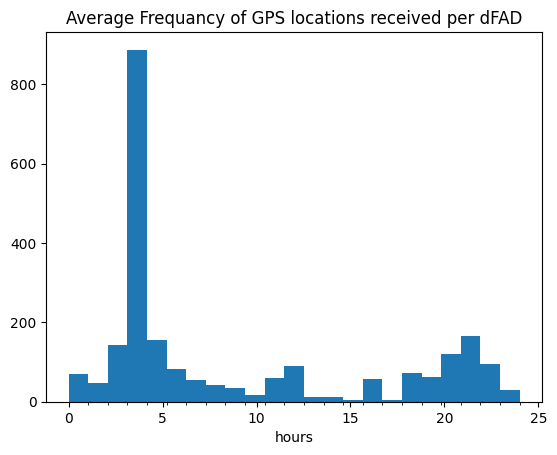

In [10]:
bins  = np.linspace(0,24,24)
print(bins)
fig, ax = plt.subplots()
ax.hist(DaylySamples["SampleFreq"], bins = bins)
ax.set_xlabel("hours")
ax.set_xticks(bins, minor=True)
ax.set_title("Average Frequancy of GPS locations received per dFAD")

In [20]:
def haversine_dist(lat1, lon1, lat2, lon2):
    from math import radians, sin, cos, atan2, sqrt
    # Convert lat and lon to radians
    lat1_rad, lon1_rad = radians(lat1), radians(lon1)
    lat2_rad, lon2_rad = radians(lat2), radians(lon2)
 
    dist_lon = lon2_rad-lon1_rad
    dist_lat = lat2_rad-lat1_rad
 
    a = sin(dist_lat/2)**2+cos(lat1_rad)*cos(lat2_rad)*sin(dist_lon/2)**2
    c = 2*atan2(sqrt(a), sqrt(1-a))
 
    R = 6371.0
 
    distance = R*c
    return distance

In [ ]:
Palmyra = shp.points(-162.078333, 5.883611,)

from shapely.ops import nearest_points
data["Nearest_point"] = nearest_points(data["geometry"], Palmyra)[0]
lat1 = np.array(data["Nearest_point"].y)
lon1 = np.array(data["Nearest_point"].x)
distance = []
for n in range(0,len(lat1)):
    temp = haversine_dist(lat1[n], lon1[n], Palmyra.y , Palmyra.x)
    distance.append(temp)

data["distance_km"] = distance

(array([193., 230., 186., 211., 209., 220., 238., 221., 216., 181., 148.,
        100.,  57.,  18.,   7.]),
 array([1.18743683e-02, 1.81187809e+01, 3.62256874e+01, 5.43325939e+01,
        7.24395004e+01, 9.05464069e+01, 1.08653313e+02, 1.26760220e+02,
        1.44867126e+02, 1.62974033e+02, 1.81080939e+02, 1.99187846e+02,
        2.17294752e+02, 2.35401659e+02, 2.53508565e+02, 2.71615472e+02]),
 <BarContainer object of 15 artists>)

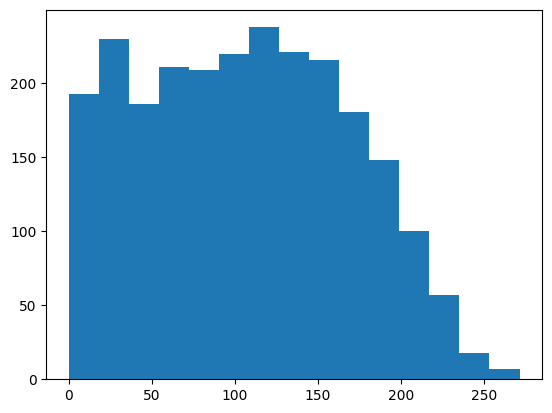

In [31]:
fig, ax = plt.subplots()
ax.hist(data["distance_km"],bins = 15)